In [172]:
import pandas as pd
import heapq

In [173]:
# parameters for baseline models
PARAMS_COMMON = {
    "TRAVEL_SPEED": 40,  # km/h
    "BOARDING_TIME": 0.5,  # minutes per passenger
    "ALIGHTING_TIME": 0.3,  # minutes per passenger
    "EARLIEST_DEPARTURE_SHIFT_MIN": -30.0,
    "PENALTY_BOARD_LATE": 20,  # boarding late penalty per passenger-minute
    "PENALTY_ALIGHT_LATE": 20,  # alighting late penalty per passenger-minute
    "REWARD_ALIGHT_EARLY": 2,  # alighting early reward per passenger-minute
    "TAU_SOFT_WINDOW_MIN": 5.0,
    "TAU_VIOLATION_PENALTY": 50.0,
    "TAU_VIOLATION_PENALTY_MULTIPLIER": 4.0,
    "MIN_BREAK_BETWEEN_SHIFTS": 60,
    "NUMERICAL_EPS": 1e-9,
    "DEMAND_EPS": 1e-6,
    "CPLEX_LOG_OUTPUT": True,
}

PARAMS_FIXED = {
    **PARAMS_COMMON,
    "TOP_K_PERIODS": None,
    "max_stops": 20,
    "max_per_combo": 10000,
    "max_routes": 70000,
}

PARAMS_DYNAMIC = {
    **PARAMS_COMMON,
    "max_stops": 20,
    "max_routes_per_period": 1800000,
    "top_k_depots_per_route": 5,
    "max_pair_neighbors": 3,
    "nn_route_cap": 2000000,
}


In [174]:
staff_schedule = pd.read_csv("data/schedule_result.csv")
WEEK_HOURS = 168
TIME_SHIFT_HOURS = 0  
staff_schedule["Start"] = (staff_schedule["Start"].astype(int) - TIME_SHIFT_HOURS) % WEEK_HOURS
staff_schedule["End"] = (staff_schedule["End"].astype(int) - TIME_SHIFT_HOURS) % WEEK_HOURS
sample_data_staff = pd.read_excel("data/Berkeley_Mock_Data.xlsx", sheet_name="staff")
staff_schedule_with_branch = pd.merge(staff_schedule, sample_data_staff, left_on="Staff", right_on="staff_id")
staff_schedule_with_branch
# Calculate the number of staff starting work at each branch at each 'Start' time
start_counts = staff_schedule_with_branch.groupby(['Start', 'branch_id']).size().reset_index(name='staff_starting_count')
display(start_counts.head())
# Calculate the number of staff ending work at each branch at each 'End' time
end_counts = staff_schedule_with_branch.groupby(['End', 'branch_id']).size().reset_index(name='staff_ending_count')
display(end_counts.head())


,Start,branch_id,staff_starting_count
0,0,_store_0001,1
1,0,_store_0003,1
2,0,_store_0004,1
3,0,_store_0005,1
4,0,_store_0012,2


,End,branch_id,staff_ending_count
0,0,_store_0001,2
1,0,_store_0002,2
2,0,_store_0004,1
3,0,_store_0005,2
4,0,_store_0011,2


Text(0.5, 1.0, 'Staff Start (+) and End (−) Over Time')

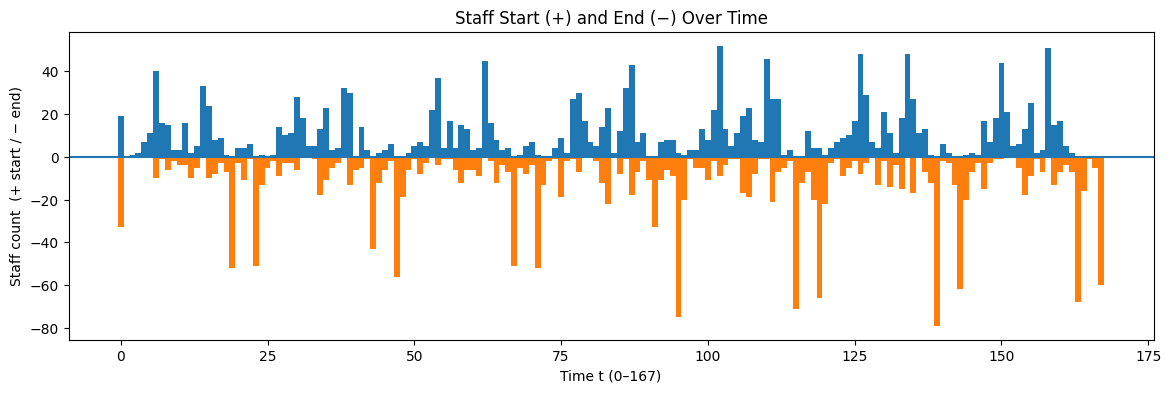

In [175]:
import numpy as np
import matplotlib.pyplot as plt

H = 168  # t = 0..167

# 1) 全局汇总（忽略 branch）
start_global = (
    start_counts
    .groupby("Start")["staff_starting_count"]
    .sum()
    .reindex(range(H), fill_value=0)
)

end_global = (
    end_counts
    .groupby("End")["staff_ending_count"]
    .sum()
    .reindex(range(H), fill_value=0)
)

# 2) 下班设为负值
end_global_neg = -end_global

# 3) 画直方图（bar chart）
plt.figure(figsize=(14,4))
plt.bar(start_global.index, start_global.values, width=1.0)
plt.bar(end_global_neg.index, end_global_neg.values, width=1.0)

plt.axhline(0)
plt.xlabel("Time t (0–167)")
plt.ylabel("Staff count  (+ start / − end)")
plt.title("Staff Start (+) and End (−) Over Time")
# plt.show()


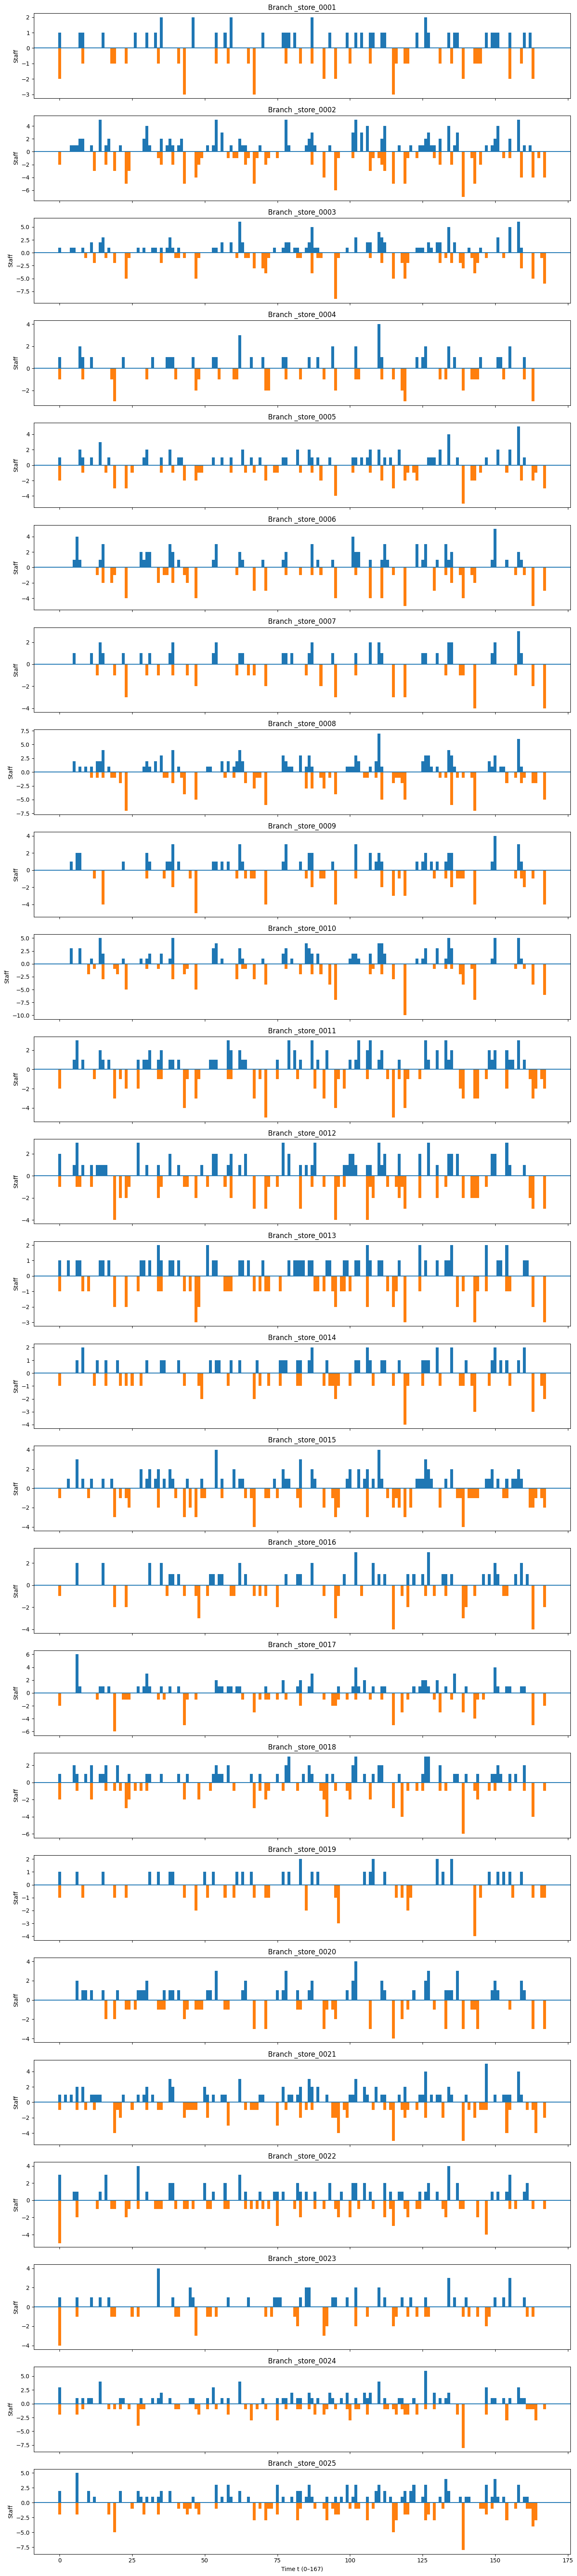

In [176]:
branches = sorted(start_counts["branch_id"].unique())

fig, axes = plt.subplots(len(branches), 1, figsize=(14, 2.5*len(branches)), sharex=True)

if len(branches) == 1:
    axes = [axes]

for ax, b in zip(axes, branches):
    sg = (
        start_counts[start_counts["branch_id"] == b]
        .groupby("Start")["staff_starting_count"]
        .sum()
        .reindex(range(H), fill_value=0)
    )
    eg = (
        end_counts[end_counts["branch_id"] == b]
        .groupby("End")["staff_ending_count"]
        .sum()
        .reindex(range(H), fill_value=0)
    )

    ax.bar(sg.index, sg.values, width=1.0)
    ax.bar(eg.index, -eg.values, width=1.0)
    ax.axhline(0)
    ax.set_title(f"Branch {b}")
    ax.set_ylabel("Staff")

axes[-1].set_xlabel("Time t (0–167)")
plt.tight_layout()
# plt.show()


In [177]:
sample_data_dist = pd.read_excel("data/Berkeley_Mock_Data.xlsx", sheet_name="branches")
sample_data_dist

,branch_id,latitude,longitude,cluster_id
0,_store_0001,24.692472,46.527043,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
1,_store_0002,24.713920,46.505920,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
2,_store_0003,24.679361,46.479360,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
3,_store_0004,24.673485,46.521971,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
4,_store_0005,24.706067,46.512484,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
5,_store_0006,24.771235,46.628195,1aea822f-8be9-431d-a346-0b7582b071ac
6,_store_0007,24.819947,46.582740,1aea822f-8be9-431d-a346-0b7582b071ac
7,_store_0008,24.780909,46.581004,1aea822f-8be9-431d-a346-0b7582b071ac
8,_store_0009,24.788255,46.601485,1aea822f-8be9-431d-a346-0b7582b071ac
9,_store_0010,24.795917,46.587474,1aea822f-8be9-431d-a346-0b7582b071ac


In [178]:
sample_data_accommodation_raw = pd.read_excel("data/Berkeley_Mock_Data.xlsx", sheet_name="accommodation")


# Keep multiple accommodation nodes with unique IDs.
sample_data_accommodation = sample_data_accommodation_raw.copy()
sample_data_accommodation['branch_id'] = sample_data_accommodation['id'].astype(str)
sample_data_accommodation = sample_data_accommodation[['branch_id', 'latitude', 'longitude', 'cluster_id']]
sample_data_accommodation = (
    sample_data_accommodation
    .dropna(subset=['branch_id', 'latitude', 'longitude'])
    .drop_duplicates(subset=['branch_id'], keep='first')
    .reset_index(drop=True)
)

sample_data_accommodation


,branch_id,latitude,longitude,cluster_id
0,d4fa274e-8690-41c7-9868-ce243c27db29,24.70,46.60,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
1,19083bcc-55cc-49f3-8fb6-6a350e4f27ae,24.72,46.61,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
2,07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,24.80,46.65,1aea822f-8be9-431d-a346-0b7582b071ac
3,decd2ba0-e893-49d8-9f11-f81b2b56bc45,24.90,46.70,df75e3dc-d14a-4ed7-a41b-10ef3979ac47
4,dcaabaa0-e128-44c1-a77d-c62b7f28a5ae,24.92,46.71,df75e3dc-d14a-4ed7-a41b-10ef3979ac47
5,fa2ebde1-3825-4092-b01a-3f07002cdb57,25.00,46.75,ba5b9796-763d-4da5-84c7-645bd32d3adc
6,8a5cc007-7d94-4e33-ab23-4d5867541a1a,25.10,46.80,662b3495-f2ff-4cb5-a62d-30dc434d807b


In [179]:
import math

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radius of Earth in kilometers

    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    distance = R * c
    return distance

In [180]:
# Combine branches and the single depot location.
all_locations = pd.concat([sample_data_dist, sample_data_accommodation], ignore_index=True)

if not all_locations['branch_id'].is_unique:
    duplicates = sorted(all_locations.loc[all_locations['branch_id'].duplicated(), 'branch_id'].unique())
    raise ValueError(f"Duplicate location IDs in distance matrix input: {duplicates}")

location_coords = all_locations.set_index('branch_id')[['latitude', 'longitude']]
location_ids = location_coords.index.tolist()
num_locations = len(location_ids)

# Create and populate distance matrix.
distance_matrix = pd.DataFrame(np.zeros((num_locations, num_locations)), index=location_ids, columns=location_ids)

for loc1_id in location_ids:
    lat1, lon1 = location_coords.loc[loc1_id]
    for loc2_id in location_ids:
        if loc1_id == loc2_id:
            continue
        lat2, lon2 = location_coords.loc[loc2_id]
        distance_matrix.loc[loc1_id, loc2_id] = haversine_km(lat1, lon1, lat2, lon2)

display(distance_matrix)


,_store_0001,_store_0002,_store_0003,_store_0004,_store_0005,_store_0006,_store_0007,_store_0008,_store_0009,_store_0010,...,_store_0023,_store_0024,_store_0025,d4fa274e-8690-41c7-9868-ce243c27db29,19083bcc-55cc-49f3-8fb6-6a350e4f27ae,07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,decd2ba0-e893-49d8-9f11-f81b2b56bc45,dcaabaa0-e128-44c1-a77d-c62b7f28a5ae,fa2ebde1-3825-4092-b01a-3f07002cdb57,8a5cc007-7d94-4e33-ab23-4d5867541a1a
_store_0001,0.000000,3.200154,5.033311,2.172560,2.109127,13.456158,15.249540,11.242813,13.036575,13.021188,...,58.312614,58.012948,57.939252,7.417830,8.921564,17.237562,28.936405,31.322671,40.932211,53.022634
_store_0002,3.200154,0.000000,4.686852,4.779648,1.096422,13.895840,14.112275,10.628972,12.706175,12.286087,...,58.020068,57.672516,57.458333,9.628793,10.534601,17.414818,28.493282,30.811328,40.228882,52.178907
_store_0003,5.033311,4.686852,0.000000,4.354737,4.474032,18.175270,18.797745,15.260609,17.284092,16.946600,...,62.646507,62.309270,62.120020,12.402422,13.949679,21.838429,33.136284,35.468036,44.910850,56.865677
_store_0004,2.172560,4.779648,4.354737,0.000000,3.747593,15.272614,17.403649,13.350360,15.078316,15.136019,...,60.244175,59.959150,59.925551,8.416732,10.287779,19.107197,30.941893,33.340990,42.984465,55.097646
_store_0005,2.109127,1.096422,4.474032,3.747593,0.000000,13.750070,14.514478,10.822986,12.817814,12.536350,...,58.188190,57.856818,57.690314,8.866484,9.971276,17.375860,28.692675,31.036972,40.528229,52.531883
_store_0006,13.456158,13.895840,18.175270,15.272614,13.750070,0.000000,7.098746,4.884316,3.294405,4.942885,...,45.026393,44.765738,44.827455,8.417241,5.986043,3.882792,16.047088,18.487011,28.249338,40.453678
_store_0007,15.249540,14.112275,18.797745,17.403649,14.514478,7.098746,0.000000,4.344363,3.999800,2.714401,...,44.260147,43.861655,43.518031,13.450880,11.449333,7.141843,14.805327,16.988190,26.179715,38.071257
_store_0008,11.242813,10.628972,15.260609,13.350360,10.822986,4.884316,4.344363,0.000000,2.223118,1.792076,...,47.393039,47.050298,46.867529,9.198927,7.378605,7.281328,17.875693,20.214081,29.733219,41.790726
_store_0009,13.036575,12.706175,17.284092,15.078316,12.817814,3.294405,3.999800,2.223118,0.000000,1.651148,...,45.373223,45.048293,44.922367,9.814654,7.638159,5.068492,15.912501,18.288771,27.906232,40.027684
_store_0010,13.021188,12.286087,16.946600,15.136019,12.536350,4.942885,2.714401,1.792076,1.651148,0.000000,...,45.748009,45.392337,45.174459,10.740230,8.742651,6.327802,16.212937,18.525324,27.994344,40.029844


In [181]:
bus_info = pd.read_excel("data/Berkeley_Mock_Data.xlsx", sheet_name="bus_info")
bus_info

,id,capacity,cluster_id,fixed_cost,cost_per_min,cost_per_km
0,_bus_0001,20,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3,345,1,1.5
1,_bus_0002,30,a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3,444,1,2.0
2,_bus_0003,20,1aea822f-8be9-431d-a346-0b7582b071ac,302,1,1.5
3,_bus_0004,30,1aea822f-8be9-431d-a346-0b7582b071ac,332,1,2.0
4,_bus_0005,20,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,432,1,1.5
5,_bus_0006,30,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,339,1,2.0
6,_bus_0007,20,ba5b9796-763d-4da5-84c7-645bd32d3adc,335,1,1.5
7,_bus_0008,30,ba5b9796-763d-4da5-84c7-645bd32d3adc,477,1,2.0
8,_bus_0009,20,662b3495-f2ff-4cb5-a62d-30dc434d807b,420,1,1.5
9,_bus_0010,30,662b3495-f2ff-4cb5-a62d-30dc434d807b,495,1,2.0


In [182]:
# ============================================================
# Bus Fleet Scheduling - Part 2
# ============================================================

import itertools
from itertools import permutations
import numpy as np
from docplex.mp.model import Model
import warnings
warnings.filterwarnings('ignore')

In [183]:
# ============================================================
# 1. Parameters and Configuration
# ============================================================

# Build vehicle parameters from vehicles + vehicle_cost_model (cost by vehicle type/model).
vehicles_df = pd.read_excel('data/Berkeley_Mock_Data.xlsx', sheet_name='vehicles')
vehicle_cost_model_df = pd.read_excel('data/Berkeley_Mock_Data.xlsx', sheet_name='vehicle_cost_model')

cost_model_by_id = vehicle_cost_model_df.set_index('id').to_dict('index')
bus_info_by_id = bus_info.set_index('id').to_dict('index')


def normalize_vehicle_type(x):
    s = str(x).strip().lower()
    if 'small' in s:
        return 'Small Bus'
    if 'large' in s:
        return 'Large Bus'
    return None


# VEHICLE_TYPES now represents cluster-level vehicle type options only:
# one entry per (cluster_id, {Small Bus, Large Bus}).
VEHICLE_TYPES = {}
missing_cost_model = []
ignored_vehicle_rows = 0

for _, row in vehicles_df.iterrows():
    is_active = bool(row.get('active', True))
    status = str(row.get('status', 'available')).lower()
    if not is_active or status != 'available':
        continue

    v_type_norm = normalize_vehicle_type(row.get('vehicle_type', None))
    if v_type_norm is None:
        ignored_vehicle_rows += 1
        continue

    cost_model_id = row.get('cost_model_id', None)
    model = cost_model_by_id.get(cost_model_id)
    if model is None:
        missing_cost_model.append((row.get('id', None), cost_model_id))
        continue

    base_info = bus_info_by_id.get(row.get('id', None), {})

    capacity = row.get('capacity', None)
    if pd.isna(capacity):
        capacity = base_info.get('capacity', None)
    if pd.isna(capacity) or capacity is None:
        continue

    cluster_id = row.get('cluster_id', None)
    if pd.isna(cluster_id):
        cluster_id = base_info.get('cluster_id', None)
    if pd.isna(cluster_id) or cluster_id is None:
        continue

    key = f"{cluster_id}__{v_type_norm.replace(' ', '_')}"
    if key not in VEHICLE_TYPES:
        VEHICLE_TYPES[key] = {
            'capacity': int(capacity),
            'fixed_cost': float(model.get('fixed_cost', 0.0)),
            'cost_per_km': float(model.get('cost_per_km', 0.0)),
            'cost_per_min': float(model.get('cost_per_hour', 0.0)) / 60.0,
            'cluster_id': cluster_id,
            'vehicle_type': v_type_norm,
            'cost_model_id': cost_model_id,
        }

if missing_cost_model:
    print('Warning: vehicles skipped due to missing cost model mapping:')
    for bus_id, cmid in missing_cost_model[:10]:
        print(f"  bus={bus_id}, cost_model_id={cmid}")
    if len(missing_cost_model) > 10:
        print(f"  ... and {len(missing_cost_model)-10} more")

if ignored_vehicle_rows:
    print(f"Ignored non-small/large vehicle rows: {ignored_vehicle_rows}")

if not VEHICLE_TYPES:
    raise ValueError('No valid Small/Large Bus options found after joining vehicles and vehicle_cost_model.')

# Cluster mapping (for c index in formulation)
BRANCH_CLUSTER = dict(zip(sample_data_dist['branch_id'], sample_data_dist['cluster_id']))
CLUSTERS = sorted(sample_data_dist['cluster_id'].dropna().unique().tolist())
BRANCHES_BY_CLUSTER = {
    c: sorted([b for b, cc in BRANCH_CLUSTER.items() if cc == c])
    for c in CLUSTERS
}

# Build multi-depot mapping per cluster from accommodation sheet.
acc_by_cluster = (
    sample_data_accommodation.groupby('cluster_id')['branch_id']
    .apply(lambda s: sorted({str(x) for x in s if pd.notna(x)}))
    .to_dict()
)
DEPOTS_BY_CLUSTER = {c: acc_by_cluster.get(c, []) for c in CLUSTERS}

missing_depot_clusters = [c for c in CLUSTERS if not DEPOTS_BY_CLUSTER.get(c)]
if missing_depot_clusters:
    raise ValueError(
        f"Missing accommodation nodes for clusters: {missing_depot_clusters}. "
        "Please check sheet 'accommodation'."
    )

# Keep a single representative depot mapping for backward-compatible code paths
# (e.g., dynamic route-first helper functions expecting cluster -> one depot).
sample_data_clusters = pd.read_excel('data/Berkeley_Mock_Data.xlsx', sheet_name='clusters')
acc_ids = set(sample_data_accommodation['branch_id'].astype(str).tolist())
DEPOT_BY_CLUSTER = {}
for _, row in sample_data_clusters.iterrows():
    cluster_id = row['id']
    depot_id = str(row['accommodation_id']) if pd.notna(row['accommodation_id']) else None
    if depot_id and depot_id in acc_ids:
        DEPOT_BY_CLUSTER[cluster_id] = depot_id

for c in CLUSTERS:
    if c not in DEPOT_BY_CLUSTER:
        DEPOT_BY_CLUSTER[c] = DEPOTS_BY_CLUSTER[c][0]

# Time windows and constraints
TRAVEL_SPEED = None  # initialized by apply_runtime_params
BOARDING_TIME = None
ALIGHTING_TIME = None
MIN_BREAK_BETWEEN_SHIFTS = None
EARLIEST_DEPARTURE_SHIFT_MIN = None

# Cost parameters
PENALTY_BOARD_LATE = None
PENALTY_ALIGHT_LATE = None
REWARD_ALIGHT_EARLY = None
TAU_SOFT_WINDOW_MIN = None
TAU_VIOLATION_PENALTY = None
TAU_VIOLATION_PENALTY_MULTIPLIER = None

print('Vehicle Configuration (Small/Large only):')
for v_key, params in VEHICLE_TYPES.items():
    print(
        f"  {v_key}: Type={params['vehicle_type']}, Capacity={params['capacity']}, "
        f"Fixed=${params['fixed_cost']}, Per km=${params['cost_per_km']}, "
        f"Per min=${params['cost_per_min']:.2f}, Cluster={params['cluster_id']}"
    )

print('Clusters:', CLUSTERS)
for c in CLUSTERS:
    depots_c = DEPOTS_BY_CLUSTER.get(c, [])
    print(f"  Cluster {c}: {len(BRANCHES_BY_CLUSTER[c])} branches, depots={depots_c}")

def apply_runtime_params(params):
    global TRAVEL_SPEED, BOARDING_TIME, ALIGHTING_TIME
    global MIN_BREAK_BETWEEN_SHIFTS, EARLIEST_DEPARTURE_SHIFT_MIN
    global PENALTY_BOARD_LATE, PENALTY_ALIGHT_LATE, REWARD_ALIGHT_EARLY, NUMERICAL_EPS, DEMAND_EPS
    global TAU_SOFT_WINDOW_MIN, TAU_VIOLATION_PENALTY, TAU_VIOLATION_PENALTY_MULTIPLIER
    TRAVEL_SPEED = float(params["TRAVEL_SPEED"])
    BOARDING_TIME = float(params["BOARDING_TIME"])
    ALIGHTING_TIME = float(params["ALIGHTING_TIME"])
    MIN_BREAK_BETWEEN_SHIFTS = float(params["MIN_BREAK_BETWEEN_SHIFTS"])
    EARLIEST_DEPARTURE_SHIFT_MIN = float(params["EARLIEST_DEPARTURE_SHIFT_MIN"])
    PENALTY_BOARD_LATE = float(params["PENALTY_BOARD_LATE"])
    PENALTY_ALIGHT_LATE = float(params["PENALTY_ALIGHT_LATE"])
    REWARD_ALIGHT_EARLY = float(params["REWARD_ALIGHT_EARLY"])
    TAU_SOFT_WINDOW_MIN = float(params["TAU_SOFT_WINDOW_MIN"])
    TAU_VIOLATION_PENALTY = float(params["TAU_VIOLATION_PENALTY"])
    TAU_VIOLATION_PENALTY_MULTIPLIER = float(params["TAU_VIOLATION_PENALTY_MULTIPLIER"])
    NUMERICAL_EPS = float(params["NUMERICAL_EPS"])
    DEMAND_EPS = float(params["DEMAND_EPS"])

# default to fixed scenario params
apply_runtime_params(PARAMS_FIXED)


Vehicle Configuration (Small/Large only):
  a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3__Small_Bus: Type=Small Bus, Capacity=20, Fixed=$200.0, Per km=$1.5, Per min=$1.00, Cluster=a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
  a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3__Large_Bus: Type=Large Bus, Capacity=30, Fixed=$300.0, Per km=$2.0, Per min=$1.00, Cluster=a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3
  1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus: Type=Small Bus, Capacity=20, Fixed=$200.0, Per km=$1.5, Per min=$1.00, Cluster=1aea822f-8be9-431d-a346-0b7582b071ac
  1aea822f-8be9-431d-a346-0b7582b071ac__Large_Bus: Type=Large Bus, Capacity=30, Fixed=$300.0, Per km=$2.0, Per min=$1.00, Cluster=1aea822f-8be9-431d-a346-0b7582b071ac
  df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Small_Bus: Type=Small Bus, Capacity=20, Fixed=$200.0, Per km=$1.5, Per min=$1.00, Cluster=df75e3dc-d14a-4ed7-a41b-10ef3979ac47
  df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Large_Bus: Type=Large Bus, Capacity=30, Fixed=$300.0, Per km=$2.0, Per min=$1.00, C

In [184]:
# ============================================================
# 2. Prepare Demand Data (Board and Alight)
# ============================================================

def prepare_demand_data(start_counts, end_counts):
    """
    Build demand[(time, branch)] = {'board': int, 'alight': int}.
    Returns demand dict, sorted branch list, and inferred horizon.
    """
    branches = sorted(set(start_counts['branch_id']).union(set(end_counts['branch_id'])))

    max_start = int(start_counts['Start'].max()) if len(start_counts) > 0 else -1
    max_end = int(end_counts['End'].max()) if len(end_counts) > 0 else -1
    horizon = max(max_start, max_end) + 1

    demand = {}
    for t in range(horizon):
        for b in branches:
            demand[(t, b)] = {'board': 0, 'alight': 0}

    for row in start_counts.itertuples(index=False):
        t = int(row.Start)
        b = row.branch_id
        demand[(t, b)]['board'] = int(row.staff_starting_count)

    for row in end_counts.itertuples(index=False):
        t = int(row.End)
        b = row.branch_id
        demand[(t, b)]['alight'] = int(row.staff_ending_count)

    return demand, branches, horizon

demand_data, branches_list, TIME_HORIZON = prepare_demand_data(start_counts, end_counts)

print(f"Inferred horizon: 0..{TIME_HORIZON - 1}")
print(f"Number of branches: {len(branches_list)}")
print("Sample demand (first 10 non-zero entries):")
shown = 0
for (t, b), val in demand_data.items():
    if val['board'] > 0 or val['alight'] > 0:
        print(f"  Time={t}, Branch={b}: Board={val['board']}, Alight={val['alight']}")
        shown += 1
        if shown >= 10:
            break


Inferred horizon: 0..167
Number of branches: 25
Sample demand (first 10 non-zero entries):
  Time=0, Branch=_store_0001: Board=1, Alight=2
  Time=0, Branch=_store_0002: Board=0, Alight=2
  Time=0, Branch=_store_0003: Board=1, Alight=0
  Time=0, Branch=_store_0004: Board=1, Alight=1
  Time=0, Branch=_store_0005: Board=1, Alight=2
  Time=0, Branch=_store_0011: Board=0, Alight=2
  Time=0, Branch=_store_0012: Board=2, Alight=1
  Time=0, Branch=_store_0013: Board=1, Alight=1
  Time=0, Branch=_store_0014: Board=0, Alight=1
  Time=0, Branch=_store_0015: Board=0, Alight=1


In [185]:
# ============================================================
# 3. Route Generation (strictly aligned with formulation)
# ============================================================

class Route:
    def __init__(self, route_id, stops, distance_matrix, time_slot, depot):
        self.route_id = route_id
        self.stops = stops
        self.time_slot = time_slot
        self.depot = depot
        self.distance = self.calculate_distance(distance_matrix)
        self.time_feasible = False
        self.best_departure_shift = 0.0
        self.tau_by_stop = {}
        self.time_cost = 0.0

    def calculate_distance(self, distance_matrix):
        """Depot -> stops -> depot total distance."""
        if len(self.stops) == 0:
            return 0.0
        if self.depot not in distance_matrix.index:
            raise ValueError(f"Depot '{self.depot}' not in distance matrix.")

        total = float(distance_matrix.at[self.depot, self.stops[0]])
        for i in range(len(self.stops) - 1):
            total += float(distance_matrix.at[self.stops[i], self.stops[i + 1]])
        total += float(distance_matrix.at[self.stops[-1], self.depot])
        return float(total)

    def _travel_minutes(self, km):
        return 60.0 * float(km) / float(TRAVEL_SPEED)

    def travel_minutes(self):
        """Total route running minutes based on depot->stops->depot distance."""
        return self._travel_minutes(self.distance)

    def _arrival_offsets(self, demand_data, distance_matrix):
        """
        Arrival offsets (minutes) from route departure time for each stop.
        Returns dict: stop -> offset_minutes.
        """
        offsets = {}
        if not self.stops:
            return offsets

        elapsed = self._travel_minutes(float(distance_matrix.at[self.depot, self.stops[0]]))
        offsets[self.stops[0]] = elapsed

        for i in range(len(self.stops) - 1):
            cur = self.stops[i]
            nxt = self.stops[i + 1]
            d = demand_data.get((self.time_slot, cur), {'board': 0, 'alight': 0})
            service = d['board'] * BOARDING_TIME + d['alight'] * ALIGHTING_TIME
            elapsed += service
            elapsed += self._travel_minutes(float(distance_matrix.at[cur, nxt]))
            offsets[nxt] = elapsed

        return offsets

    def calculate_load_profile(self, demand_data):
        """
        L_init and L_k profile:
        L_k = L_init + sum_{i<=k}(board_i - alight_i)
        """
        changes = []
        for b in self.stops:
            d = demand_data.get((self.time_slot, b), {'board': 0, 'alight': 0})
            changes.append(d['board'] - d['alight'])

        cum = 0
        min_cum = 0
        for c in changes:
            cum += c
            min_cum = min(min_cum, cum)

        init_load = max(0, -min_cum)

        load_profile = []
        cur = init_load
        for c in changes:
            cur += c
            load_profile.append(cur)

        return init_load, load_profile

    def is_capacity_feasible(self, vehicle_capacity, demand_data):
        init_load, load_profile = self.calculate_load_profile(demand_data)
        if init_load > vehicle_capacity:
            return False
        return all(0 <= load <= vehicle_capacity for load in load_profile)

    def build_schedule_details(self, demand_data, vehicle_capacity):
        """
        Build per-stop operational details for the selected route and vehicle.
        """
        init_load, load_profile = self.calculate_load_profile(demand_data)

        board_by_stop = {}
        alight_by_stop = {}
        load_before_stop = {}
        load_after_stop = {}
        remaining_seats_after_stop = {}

        current_load = float(init_load)
        for idx, stop in enumerate(self.stops):
            d = demand_data.get((self.time_slot, stop), {'board': 0, 'alight': 0})
            board = float(d.get('board', 0))
            alight = float(d.get('alight', 0))

            board_by_stop[stop] = board
            alight_by_stop[stop] = alight
            load_before_stop[stop] = current_load

            if idx < len(load_profile):
                current_load = float(load_profile[idx])
            else:
                current_load = current_load + board - alight

            load_after_stop[stop] = current_load
            remaining_seats_after_stop[stop] = float(vehicle_capacity) - current_load

        peak_load = max([float(init_load)] + [float(x) for x in load_profile]) if self.stops else float(init_load)
        min_remaining = (
            min(remaining_seats_after_stop.values())
            if remaining_seats_after_stop else float(vehicle_capacity) - float(init_load)
        )

        return {
            'init_load': float(init_load),
            'board_by_stop': board_by_stop,
            'alight_by_stop': alight_by_stop,
            'load_before_stop': load_before_stop,
            'load_after_stop': load_after_stop,
            'remaining_seats_after_stop': remaining_seats_after_stop,
            'peak_load': float(peak_load),
            'min_remaining_seats': float(min_remaining),
            'capacity_utilization_peak': (
                float(peak_load) / float(vehicle_capacity) if float(vehicle_capacity) > 0 else float('nan')
            ),
        }

    def evaluate_time_feasibility(self, demand_data, distance_matrix):
        """
        Soft-evaluate tau constraints using one route departure shift variable delta.
        tau_b = delta + arrival_offset_b, where target for period t is fixed.
        Small directional violations are allowed and penalized in the objective.
        """
        offsets = self._arrival_offsets(demand_data, distance_matrix)
        lower = float(EARLIEST_DEPARTURE_SHIFT_MIN)
        tol = max(0.0, float(TAU_SOFT_WINDOW_MIN))
        candidates = [lower]
        for b in self.stops:
            for bp in (-offsets[b] - tol, -offsets[b], -offsets[b] + tol):
                if bp >= lower - 1e-9:
                    candidates.append(float(bp))

        def violation_penalty(delta):
            total = 0.0
            base_rate = max(0.0, float(TAU_VIOLATION_PENALTY))
            excess_rate = base_rate * max(1.0, float(TAU_VIOLATION_PENALTY_MULTIPLIER))
            for b in self.stops:
                d = demand_data.get((self.time_slot, b), {'board': 0, 'alight': 0})
                tau = delta + offsets[b]
                if d['board'] > 0:
                    violation_board = max(0.0, -tau)
                    inside = min(violation_board, tol)
                    outside = max(0.0, violation_board - tol)
                    total += base_rate * inside + excess_rate * outside
                if d['alight'] > 0:
                    violation_alight = max(0.0, tau)
                    inside = min(violation_alight, tol)
                    outside = max(0.0, violation_alight - tol)
                    total += base_rate * inside + excess_rate * outside
            return total

        def time_cost(delta):
            total = 0.0
            for b in self.stops:
                tau = delta + offsets[b]
                d = demand_data.get((self.time_slot, b), {'board': 0, 'alight': 0})
                total += PENALTY_BOARD_LATE * d['board'] * max(0.0, tau)
                total += PENALTY_ALIGHT_LATE * d['alight'] * max(0.0, tau)
                if d['alight'] > 0:
                    total -= REWARD_ALIGHT_EARLY * d['alight'] * max(0.0, -tau)
            return total + violation_penalty(delta)

        best_delta = min(candidates, key=time_cost)

        self.tau_by_stop = {b: best_delta + offsets[b] for b in self.stops}

        self.time_feasible = True
        self.best_departure_shift = float(best_delta)
        self.time_cost = max(0.0, float(time_cost(best_delta)))
        return True

    def calculate_cost(self, vehicle_type):
        """
        C_{r,v,t} = K_v + alpha_v*Dist_r + eta_v*TravelMin_r
                    + beta*sum(max(0,tau)) - gamma*sum(max(0,-tau))
        where tau terms are precomputed in evaluate_time_feasibility.
        """
        params = VEHICLE_TYPES[vehicle_type]
        return float(
            params['fixed_cost']
            + params['cost_per_km'] * self.distance
            + params['cost_per_min'] * self.travel_minutes()
            + self.time_cost
        )


def generate_routes_for_period(
    time_slot, demand_data, branches_list, distance_matrix, depot_ids,
    max_stops=None, max_per_combo=None, max_routes=None
):
    routes = []

    if max_stops is None:
        max_stops = int(PARAMS_FIXED["max_stops"])
    if max_per_combo is None:
        max_per_combo = int(PARAMS_FIXED["max_per_combo"])
    if max_routes is None:
        max_routes = int(PARAMS_FIXED["max_routes"])

    active_branches = []
    for b in branches_list:
        d = demand_data.get((time_slot, b), {'board': 0, 'alight': 0})
        if d['board'] > 0 or d['alight'] > 0:
            active_branches.append(b)

    if not active_branches:
        return routes

    depots = [str(d) for d in depot_ids if pd.notna(d)]
    depots = list(dict.fromkeys(depots))
    if not depots:
        return routes

    # Keep overall route budget roughly stable when enabling multiple depots.
    per_depot_max_routes = max(1, int(max_routes) // len(depots))

    for dep_idx, depot_id in enumerate(depots):
        depot_routes = []
        route_id = 0

        # Single-stop routes
        for b in active_branches:
            route = Route(f"R_{time_slot}_{dep_idx}_{route_id}", [b], distance_matrix, time_slot, depot_id)
            route.evaluate_time_feasibility(demand_data, distance_matrix)
            depot_routes.append(route)
            route_id += 1
            if len(depot_routes) >= per_depot_max_routes:
                break

        # Multi-stop routes
        if len(depot_routes) < per_depot_max_routes:
            max_len = min(max_stops, len(active_branches))
            for num_stops in range(2, max_len + 1):
                for combo in itertools.combinations(active_branches, num_stops):
                    for perm in itertools.islice(itertools.permutations(combo), max_per_combo):
                        stop_list = list(perm)
                        route = Route(
                            f"R_{time_slot}_{dep_idx}_{route_id}",
                            stop_list,
                            distance_matrix,
                            time_slot,
                            depot_id,
                        )
                        route.evaluate_time_feasibility(demand_data, distance_matrix)
                        depot_routes.append(route)
                        route_id += 1
                        if len(depot_routes) >= per_depot_max_routes:
                            break
                    if len(depot_routes) >= per_depot_max_routes:
                        break
                if len(depot_routes) >= per_depot_max_routes:
                    break

        routes.extend(depot_routes)

    return routes




print('Route generation function (strict version) defined.')


Route generation function (strict version) defined.


In [186]:
# ============================================================
# 4. Generate Routes by Cluster and Time Period
# ============================================================

selected_periods_by_cluster = {}
all_routes_by_cluster = {}

# Strict formulation: use all periods with demand unless user explicitly truncates.
apply_runtime_params(PARAMS_FIXED)
TOP_K_PERIODS = PARAMS_FIXED.get("TOP_K_PERIODS", None)

for c in CLUSTERS:
    branches_c = BRANCHES_BY_CLUSTER[c]
    depots_c = DEPOTS_BY_CLUSTER[c]

    periods_with_demand = sorted({
        t for (t, b), d in demand_data.items()
        if b in branches_c and (d['board'] + d['alight'] > 0)
    })

    if TOP_K_PERIODS is None:
        selected_periods = periods_with_demand
    else:
        demand_totals = []
        for t in periods_with_demand:
            total = sum(demand_data[(t, b)]['board'] + demand_data[(t, b)]['alight'] for b in branches_c)
            demand_totals.append((t, total))
        demand_totals.sort(key=lambda x: x[1], reverse=True)
        selected_periods = sorted([t for t, _ in demand_totals[:min(TOP_K_PERIODS, len(demand_totals))]])

    selected_periods_by_cluster[c] = selected_periods
    all_routes_by_cluster[c] = {}

    print(f"Cluster {c}: selected {len(selected_periods)} periods, depots={depots_c}")

    for t in selected_periods:
        routes = generate_routes_for_period(
            t, demand_data, branches_c, distance_matrix, depots_c,
            max_stops=int(PARAMS_FIXED["max_stops"]),
            max_per_combo=int(PARAMS_FIXED["max_per_combo"]),
            max_routes=int(PARAMS_FIXED["max_routes"])
        )

        all_routes_by_cluster[c][t] = routes

    total_routes_c = sum(len(v) for v in all_routes_by_cluster[c].values())
    print(f"  Cluster {c}: total candidate routes = {total_routes_c}")


Cluster 1aea822f-8be9-431d-a346-0b7582b071ac: selected 117 periods, depots=['07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc']
  Cluster 1aea822f-8be9-431d-a346-0b7582b071ac: total candidate routes = 12610
Cluster 662b3495-f2ff-4cb5-a62d-30dc434d807b: selected 146 periods, depots=['8a5cc007-7d94-4e33-ab23-4d5867541a1a']
  Cluster 662b3495-f2ff-4cb5-a62d-30dc434d807b: total candidate routes = 9453
Cluster a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3: selected 139 periods, depots=['19083bcc-55cc-49f3-8fb6-6a350e4f27ae', 'd4fa274e-8690-41c7-9868-ce243c27db29']
  Cluster a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3: total candidate routes = 16722
Cluster ba5b9796-763d-4da5-84c7-645bd32d3adc: selected 130 periods, depots=['fa2ebde1-3825-4092-b01a-3f07002cdb57']
  Cluster ba5b9796-763d-4da5-84c7-645bd32d3adc: total candidate routes = 7089
Cluster df75e3dc-d14a-4ed7-a41b-10ef3979ac47: selected 144 periods, depots=['dcaabaa0-e128-44c1-a77d-c62b7f28a5ae', 'decd2ba0-e893-49d8-9f11-f81b2b56bc45']
  Cluster df75e3dc-d14a-4e

In [187]:
# ============================================================
# 5. Build and Solve CPLEX Optimization Model (strict formulation)
# ============================================================

def solve_bus_scheduling_strict(
    all_routes_by_cluster,
    demand_data,
    branches_by_cluster,
    selected_periods_by_cluster,
    vehicle_types,
):
    """
    Strictly aligned model:
    min sum_{t,c,r,v} C_{r,v,t} * lambda_{r,v,t}

    s.t. sum_{r in R_c,t} sum_v a_{b,r} * lambda_{r,v,t} = 1
         for each (t,b) with demand > 0
    """
    model = Model(name='Bus_Fleet_Scheduling_Strict')

    lambda_vars = {}
    valid = {}
    route_map = {}
    route_cost = {}
    bad_cost_keys = []

    print('Creating lambda variables for valid (capacity/time) and cluster-compatible combinations...')

    for c, periods in selected_periods_by_cluster.items():
        for t in periods:
            for route in all_routes_by_cluster[c][t]:
                route_map[(c, route.route_id, t)] = route
                for v_type, params in vehicle_types.items():
                    # Enforce vehicle-cluster compatibility (None means shared/global).
                    v_cluster = params.get('cluster_id', None)
                    if pd.notna(v_cluster) and v_cluster is not None and v_cluster != c:
                        continue

                    cap_ok = route.is_capacity_feasible(params['capacity'], demand_data)
                    time_ok = route.time_feasible
                    if not (cap_ok and time_ok):
                        continue

                    cost_val = float(route.calculate_cost(v_type))
                    if not np.isfinite(cost_val):
                        bad_cost_keys.append((c, t, route.route_id, v_type, cost_val))
                        continue

                    key = (c, route.route_id, v_type, t)
                    lambda_vars[key] = model.binary_var(name=f"lambda_{c}_{route.route_id}_{v_type}_{t}")
                    valid[key] = 1
                    route_cost[key] = cost_val

    print(f"Lambda variables (valid only): {len(lambda_vars)}")
    if bad_cost_keys:
        print('Skipped non-finite route costs:')
        for c, t, r_id, v_type, cost_val in bad_cost_keys[:20]:
            print(f"  c={c}, t={t}, route={r_id}, vehicle={v_type}, cost={cost_val}")
        if len(bad_cost_keys) > 20:
            print(f"  ... and {len(bad_cost_keys)-20} more")

    if not lambda_vars:
        print('No valid route-vehicle combinations available. Model is infeasible by construction.')
        return None, None, model, valid

    # Objective
    model.minimize(model.sum(
        route_cost[(c, route_id, v_type, t)] * var
        for (c, route_id, v_type, t), var in lambda_vars.items()
    ))

    # Demand coverage: exactly one route (strict)
    print('Adding strict coverage constraints (=1)...')
    coverage_count = 0
    missing_cover = []

    for c, periods in selected_periods_by_cluster.items():
        branches_c = branches_by_cluster[c]

        for t in periods:
            for b in branches_c:
                d = demand_data.get((t, b), {'board': 0, 'alight': 0})
                if d['board'] + d['alight'] <= 0:
                    continue

                terms = []
                for route in all_routes_by_cluster[c][t]:
                    if b not in route.stops:
                        continue
                    for v_type in vehicle_types.keys():
                        key = (c, route.route_id, v_type, t)
                        if key in lambda_vars:
                            terms.append(lambda_vars[key])

                if not terms:
                    missing_cover.append((c, t, b))
                    continue

                model.add_constraint(
                    model.sum(terms) == 1,
                    ctname=f"cover_{c}_t{t}_b{b}",
                )
                coverage_count += 1

    print(f"Coverage constraints: {coverage_count}")
    if missing_cover:
        print('Warning: uncovered demand points (no valid route-vehicle combo found):')
        for c, t, b in missing_cover[:20]:
            print(f"  c={c}, t={t}, b={b}")
        if len(missing_cover) > 20:
            print(f"  ... and {len(missing_cover)-20} more")
        print(f"Total uncovered demand points: {len(missing_cover)}")

    print('Solving strict model...')
    solution = model.solve(log_output=bool(PARAMS_FIXED.get("CPLEX_LOG_OUTPUT", True)))

    if not solution:
        print(f"No solution found. Status: {model.solve_details.status}")
        return None, None, model, valid

    print(f"Status: {model.solve_details.status}")
    print(f"Objective: ${solution.objective_value:,.2f}")

    selected_routes = []
    for (c, route_id, v_type, t), var in lambda_vars.items():
        if var.solution_value > 0.5:
            route = route_map[(c, route_id, t)]
            schedule_details = route.build_schedule_details(
                demand_data=demand_data,
                vehicle_capacity=vehicle_types[v_type]['capacity'],
            )
            selected_routes.append({
                'cluster': c,
                'time': t,
                'route_id': route_id,
                'vehicle_type': v_type,
                'bus_kind': vehicle_types[v_type].get('vehicle_type'),
                'stops': route.stops,
                'depot_id': route.depot,
                'distance': route.distance,
                'cost': route_cost[(c, route_id, v_type, t)],
                'capacity': vehicle_types[v_type]['capacity'],
                'time_feasible': route.time_feasible,
                'departure_shift_min': route.best_departure_shift,
                'tau_by_stop': route.tau_by_stop,
                'init_load': schedule_details['init_load'],
                'board_by_stop': schedule_details['board_by_stop'],
                'alight_by_stop': schedule_details['alight_by_stop'],
                'load_before_stop': schedule_details['load_before_stop'],
                'load_after_stop': schedule_details['load_after_stop'],
                'remaining_seats_after_stop': schedule_details['remaining_seats_after_stop'],
                'peak_load': schedule_details['peak_load'],
                'min_remaining_seats': schedule_details['min_remaining_seats'],
                'capacity_utilization_peak': schedule_details['capacity_utilization_peak'],
            })

    # Post-solve audit: print demand points that still received no service.
    served_points = set()
    for r in selected_routes:
        c = r['cluster']
        t = r['time']
        for b in r['stops']:
            served_points.add((c, t, b))

    unmet_points = []
    for c, periods in selected_periods_by_cluster.items():
        for t in periods:
            for b in branches_by_cluster[c]:
                d = demand_data.get((t, b), {'board': 0, 'alight': 0})
                if d['board'] + d['alight'] <= 0:
                    continue
                if (c, t, b) not in served_points:
                    unmet_points.append((c, t, b, d['board'], d['alight']))

    if unmet_points:
        print('Unserved demand points after optimization:')
        for c, t, b, board, alight in unmet_points[:50]:
            print(f"  c={c}, t={t}, b={b}, board={board}, alight={alight}")
        if len(unmet_points) > 50:
            print(f"  ... and {len(unmet_points) - 50} more")
        print(f"Total unserved demand points: {len(unmet_points)}")
    else:
        print('All demand points are covered by selected routes.')

    return solution, selected_routes, model, valid


solution, selected_routes, model, valid_indicator = solve_bus_scheduling_strict(
    all_routes_by_cluster=all_routes_by_cluster,
    demand_data=demand_data,
    branches_by_cluster=BRANCHES_BY_CLUSTER,
    selected_periods_by_cluster=selected_periods_by_cluster,
    vehicle_types=VEHICLE_TYPES,
)


Creating lambda variables for valid (capacity/time) and cluster-compatible combinations...
Lambda variables (valid only): 131202
Adding strict coverage constraints (=1)...
Coverage constraints: 1956
Solving strict model...
Version identifier: 22.1.1.0 | 2022-11-27 | 9160aff4d
CPXPARAM_Read_DataCheck                          1
Found incumbent of value 478205.706065 after 0.02 sec. (12.95 ticks)
Found incumbent of value 285141.300955 after 0.03 sec. (16.73 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 439 rows and 124623 columns.
Reduced MIP has 1517 rows, 6427 columns, and 14832 nonzeros.
Reduced MIP has 6427 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.14 sec. (122.56 ticks)
Probing time = 0.00 sec. (2.21 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 333 rows and 777 columns.
Reduced MIP has 1184 rows, 5650 columns, and 13500 nonzeros.
Reduced MIP has 5650 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.02 sec. (7.38 ticks)
Pro

In [188]:
# ============================================================
# 6. Display and Analyze Results
# ============================================================

if selected_routes:
    # Create results DataFrame
    results_df = pd.DataFrame(selected_routes)
    
    print(f"\n{'='*80}")
    print(f"BUS FLEET SCHEDULING RESULTS")
    print(f"{'='*80}\n")
    
    print(f"Total Routes Selected: {len(selected_routes)}")
    print(f"Total Cost: ${solution.objective_value:,.2f}\n")
    
    # Summary by vehicle type
    print("Vehicle Utilization:")
    vehicle_summary = results_df.groupby('vehicle_type').agg({
        'route_id': 'count',
        'distance': 'sum',
        'cost': 'sum'
    }).rename(columns={'route_id': 'num_routes'})
    
    for v_type, row in vehicle_summary.iterrows():
        print(f"  {v_type}: {int(row['num_routes'])} routes, "
              f"{row['distance']:.1f} km, ${row['cost']:,.2f}")
    
    print("\n" + "="*80)
    print("Detailed Route Schedule (first 15 routes):")
    print("="*80)
    
    for i, route_info in enumerate(selected_routes[:15]):
        print(f"\nRoute {i+1}:")
        print(f"  Time Slot: {route_info['time']} (Hour {route_info['time']} of week)")
        print(f"  Vehicle: {route_info['vehicle_type']}")
        print(f"  Stops: {' -> '.join(route_info['stops'])}")
        print(f"  Distance: {route_info['distance']:.2f} km")
        print(f"  Cost: ${route_info['cost']:.2f}")
        print(
            f"  Load Summary: init={route_info.get('init_load', 0):.1f}, "
            f"peak={route_info.get('peak_load', 0):.1f}, "
            f"min remaining seats={route_info.get('min_remaining_seats', 0):.1f}, "
            f"peak util={100.0*route_info.get('capacity_utilization_peak', 0):.1f}%"
        )

        # Show stop-level operational details
        print("  Stop-level details:")
        for stop in route_info['stops']:
            board = route_info.get('board_by_stop', {}).get(stop, 0)
            alight = route_info.get('alight_by_stop', {}).get(stop, 0)
            load_before = route_info.get('load_before_stop', {}).get(stop, 0)
            load_after = route_info.get('load_after_stop', {}).get(stop, 0)
            remain = route_info.get('remaining_seats_after_stop', {}).get(stop, 0)
            print(
                f"    {stop}: board={board}, alight={alight}, "
                f"load_before={load_before:.1f}, load_after={load_after:.1f}, remaining={remain:.1f}"
            )
    
    if len(selected_routes) > 15:
        print(f"\n... and {len(selected_routes) - 15} more routes")
    
    # Display full results table
    print("\n" + "="*80)
    display(results_df)
    
    # Save results
    results_df.to_csv("results/bus_fleet_schedule.csv", index=False)
    print("\nResults saved to 'results/bus_fleet_schedule.csv'")
    
else:
    print("No solution was found. Please check the model constraints and data.")



BUS FLEET SCHEDULING RESULTS

Total Routes Selected: 891
Total Cost: $278,250.09

Vehicle Utilization:
  1aea822f-8be9-431d-a346-0b7582b071ac__Large_Bus: 5 routes, 105.2 km, $1,868.35
  1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus: 168 routes, 2431.9 km, $51,787.75
  662b3495-f2ff-4cb5-a62d-30dc434d807b__Large_Bus: 1 routes, 26.7 km, $393.45
  662b3495-f2ff-4cb5-a62d-30dc434d807b__Small_Bus: 176 routes, 4166.7 km, $61,046.53
  a1e8b5a7-8ec4-44d9-8cb9-11fbb1341ec3__Small_Bus: 187 routes, 4240.1 km, $61,444.60
  ba5b9796-763d-4da5-84c7-645bd32d3adc__Small_Bus: 170 routes, 2672.6 km, $51,438.85
  df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Small_Bus: 184 routes, 1300.9 km, $50,270.57

Detailed Route Schedule (first 15 routes):

Route 1:
  Time Slot: 4 (Hour 4 of week)
  Vehicle: 1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus
  Stops: _store_0010 -> _store_0009
  Distance: 13.05 km
  Cost: $318.68
  Load Summary: init=0.0, peak=4.0, min remaining seats=16.0, peak util=20.0%
  Stop-level det

,cluster,time,route_id,vehicle_type,bus_kind,stops,depot_id,distance,cost,capacity,...,tau_by_stop,init_load,board_by_stop,alight_by_stop,load_before_stop,load_after_stop,remaining_seats_after_stop,peak_load,min_remaining_seats,capacity_utilization_peak
0,1aea822f-8be9-431d-a346-0b7582b071ac,4,R_4_0_3,1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus,Small Bus,"[_store_0010, _store_0009]",07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,13.047442,318.676751,20,...,"{'_store_0010': 0.0, '_store_0009': 3.97672125...",0.0,"{'_store_0010': 3.0, '_store_0009': 1.0}","{'_store_0010': 0.0, '_store_0009': 0.0}","{'_store_0010': 0.0, '_store_0009': 3.0}","{'_store_0010': 3.0, '_store_0009': 4.0}","{'_store_0010': 17.0, '_store_0009': 16.0}",4.0,16.0,0.20
1,1aea822f-8be9-431d-a346-0b7582b071ac,5,R_5_0_0,1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus,Small Bus,[_store_0006],07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,7.765585,223.296755,20,...,{'_store_0006': 0.0},0.0,{'_store_0006': 1.0},{'_store_0006': 0.0},{'_store_0006': 0.0},{'_store_0006': 1.0},{'_store_0006': 19.0},1.0,19.0,0.05
2,1aea822f-8be9-431d-a346-0b7582b071ac,5,R_5_0_8,1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus,Small Bus,"[_store_0008, _store_0007]",07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,18.767534,406.633492,20,...,"{'_store_0008': 0.0, '_store_0007': 7.51654450...",0.0,"{'_store_0008': 2.0, '_store_0007': 1.0}","{'_store_0008': 0.0, '_store_0007': 0.0}","{'_store_0008': 0.0, '_store_0007': 2.0}","{'_store_0008': 2.0, '_store_0007': 3.0}","{'_store_0008': 18.0, '_store_0007': 17.0}",3.0,17.0,0.15
3,1aea822f-8be9-431d-a346-0b7582b071ac,6,R_6_0_0,1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus,Small Bus,[_store_0006],07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,7.765585,223.296755,20,...,{'_store_0006': 0.0},0.0,{'_store_0006': 4.0},{'_store_0006': 0.0},{'_store_0006': 0.0},{'_store_0006': 4.0},{'_store_0006': 16.0},4.0,16.0,0.20
4,1aea822f-8be9-431d-a346-0b7582b071ac,6,R_6_0_1,1aea822f-8be9-431d-a346-0b7582b071ac__Small_Bus,Small Bus,[_store_0009],07a3adbd-1247-4ec5-b7c2-823e3ae5f7bc,10.136984,230.410953,20,...,{'_store_0009': 0.0},0.0,{'_store_0009': 2.0},{'_store_0009': 0.0},{'_store_0009': 0.0},{'_store_0009': 2.0},{'_store_0009': 18.0},2.0,18.0,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,162,R_162_1_12,df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Small_Bus,Small Bus,"[_store_0012, _store_0015, _store_0011]",decd2ba0-e893-49d8-9f11-f81b2b56bc45,7.274651,221.823953,20,...,"{'_store_0012': -27.592040947669982, '_store_0...",5.0,"{'_store_0012': 0.0, '_store_0015': 0.0, '_sto...","{'_store_0012': 2.0, '_store_0015': 2.0, '_sto...","{'_store_0012': 5.0, '_store_0015': 3.0, '_sto...","{'_store_0012': 3.0, '_store_0015': 1.0, '_sto...","{'_store_0012': 17.0, '_store_0015': 19.0, '_s...",5.0,17.0,0.25
887,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,163,R_163_1_224,df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Small_Bus,Small Bus,"[_store_0011, _store_0015, _store_0012, _store...",decd2ba0-e893-49d8-9f11-f81b2b56bc45,10.876524,232.629571,20,...,"{'_store_0011': -26.54157696002828, '_store_00...",13.0,"{'_store_0011': 0.0, '_store_0015': 0.0, '_sto...","{'_store_0011': 3.0, '_store_0015': 2.0, '_sto...","{'_store_0011': 13.0, '_store_0015': 10.0, '_s...","{'_store_0011': 10.0, '_store_0015': 8.0, '_st...","{'_store_0011': 10.0, '_store_0015': 12.0, '_s...",13.0,10.0,0.65
888,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,164,R_164_1_2,df75e3dc-d14a-4ed7-a41b-10ef3979ac47__Small_Bus,Small Bus,"[_store_0011, _store_0015]",decd2ba0-e893-49d8-9f11-f81b2b56bc45,5.696426,217.089279,20,...,"{'_store_0011': -26.54157696002828, '_store_00...",3.0,"{'_store_0011': 0.0, '_store_0015': 0.0}","{'_store_0011': 2.0, '_store_0015': 1.0}","{'_store_0011': 3.0, '_store_0015': 1.0}","{'_store_0011': 1.0, '_store_0015': 0.0}","{'_store_0011': 19.0, '_store_0015': 20.0}",3.0,19.0,0.15
889,df75e3dc-d14a-4ed7-a41b-10ef3979ac47,166,R_166_1_12,df75e3dc-d14a-4ed7-a41b-10ef


Results saved to 'results/bus_fleet_schedule.csv'


**Dynamic clusters**


In [189]:
# ============================================================
# 6. Dynamic Clustering Refinement - Route-First (hybrid candidate pool)
# ============================================================

from collections import defaultdict


def _branch_direction(t, b, demand_data):
    d = demand_data.get((t, b), {'board': 0, 'alight': 0})
    board = float(d.get('board', 0))
    alight = float(d.get('alight', 0))
    if board > 0 and alight <= 0:
        return 'pick_only'
    if alight > 0 and board <= 0:
        return 'drop_only'
    if board > 0 and alight > 0:
        return 'mixed'
    return 'inactive'


def _savings_route_lists(subset_branches, distance_matrix, depot_id, max_stops=None):
    if max_stops is None:
        max_stops = int(PARAMS_DYNAMIC["max_stops"])
    if not subset_branches:
        return []

    current_routes = [[b] for b in subset_branches]

    savings = []
    for i, j in itertools.combinations(subset_branches, 2):
        s = float(distance_matrix.at[depot_id, i]) + float(distance_matrix.at[depot_id, j]) - float(distance_matrix.at[i, j])
        savings.append((s, i, j))
    savings.sort(reverse=True, key=lambda x: x[0])

    for _s, i, j in savings:
        route_i = None
        route_j = None
        for r in current_routes:
            if r and r[-1] == i:
                route_i = r
            if r and r[0] == j:
                route_j = r

        if route_i is None or route_j is None or route_i is route_j:
            continue

        merged = route_i + route_j
        if len(set(merged)) != len(merged):
            continue
        if len(merged) > max_stops:
            continue

        current_routes.remove(route_i)
        current_routes.remove(route_j)
        current_routes.append(merged)

    unique = []
    seen = set()
    for r in current_routes:
        key = tuple(r)
        if key not in seen:
            seen.add(key)
            unique.append(r)
    return unique


def _nearest_neighbor_route_lists(active_branches, distance_matrix, max_stops=None):
    """Construct short routes using nearest-neighbor expansion for diversity."""
    if max_stops is None:
        max_stops = int(PARAMS_DYNAMIC["max_stops"])
    routes = []
    for start in active_branches:
        route = [start]
        remaining = set(active_branches) - {start}
        while remaining and len(route) < max_stops:
            last = route[-1]
            nxt = min(remaining, key=lambda b: float(distance_matrix.at[last, b]))
            route.append(nxt)
            remaining.remove(nxt)
        routes.append(route)
    return routes


def _pair_trip_route_lists(active_branches, distance_matrix, max_pair_neighbors=None):
    if max_pair_neighbors is None:
        max_pair_neighbors = int(PARAMS_DYNAMIC["max_pair_neighbors"])
    """
    Build additional 2-stop and 3-stop candidates from nearest neighbors.
    """
    routes = []
    for b in active_branches:
        others = [x for x in active_branches if x != b]
        if not others:
            continue
        nn = sorted(others, key=lambda x: float(distance_matrix.at[b, x]))[:max_pair_neighbors]
        for n1 in nn:
            routes.append([b, n1])
            rem = [x for x in nn if x != n1]
            for n2 in rem[:2]:
                if n2 != b and n2 != n1:
                    routes.append([b, n1, n2])
    return routes


def _rank_depots_for_stop_list(stop_list, depot_by_cluster, distance_matrix):
    depot_items = list(depot_by_cluster.items())
    if not depot_items:
        raise ValueError('No depots found for dynamic route-first.')

    first_stop = stop_list[0]
    last_stop = stop_list[-1]

    ranked = []
    for c, d in depot_items:
        score = float(distance_matrix.at[d, first_stop]) + float(distance_matrix.at[last_stop, d])
        ranked.append((c, d, score))
    ranked.sort(key=lambda x: x[2])
    return ranked


def _nearest_depot_for_stop_list(stop_list, depot_by_cluster, distance_matrix):
    c, d, _ = _rank_depots_for_stop_list(stop_list, depot_by_cluster, distance_matrix)[0]
    return c, d


def _score_stop_list(stop_list, t, demand_data, distance_matrix, depot_id):
    demand_sum = sum(
        float(demand_data.get((t, b), {'board': 0, 'alight': 0})['board'] + demand_data.get((t, b), {'board': 0, 'alight': 0})['alight'])
        for b in stop_list
    )
    if demand_sum <= 0:
        demand_sum = float(PARAMS_DYNAMIC["DEMAND_EPS"])

    dist = float(distance_matrix.at[depot_id, stop_list[0]])
    for i in range(len(stop_list) - 1):
        dist += float(distance_matrix.at[stop_list[i], stop_list[i + 1]])
    dist += float(distance_matrix.at[stop_list[-1], depot_id])

    # smaller is better
    return dist / demand_sum, dist, demand_sum


def build_dynamic_route_first_inputs(
    demand_data,
    distance_matrix,
    branch_cluster,
    depot_by_cluster,
    vehicle_types,
    max_stops=None,
    max_routes_per_period=None,
    top_k_depots_per_route=None,
    baseline_routes=None,
):
    """
    Hybrid route-first candidate pool:
    - single-stop (coverage robustness)
    - nearest-neighbor short routes
    - savings routes on direction subsets
    then keep top-K by route efficiency score.
    """
    dynamic_routes = {}
    refined_meta = {}

    periods = sorted({t for (t, _b), d in demand_data.items() if (d['board'] + d['alight']) > 0})

    for t in periods:
        active = [
            b for (tt, b), d in demand_data.items()
            if tt == t and (d['board'] + d['alight'] > 0)
        ]
        active = sorted(set(active))
        if not active:
            continue

        drop_only = [b for b in active if _branch_direction(t, b, demand_data) == 'drop_only']
        pick_only = [b for b in active if _branch_direction(t, b, demand_data) == 'pick_only']
        mixed = [b for b in active if _branch_direction(t, b, demand_data) == 'mixed']

        represented_static = sorted({branch_cluster[b] for b in active if b in branch_cluster})
        dominant_static = max(
            represented_static,
            key=lambda c: sum(
                float(demand_data.get((t, b), {'board': 0, 'alight': 0})['board'] + demand_data.get((t, b), {'board': 0, 'alight': 0})['alight'])
                for b in active if branch_cluster.get(b) == c
            ),
        ) if represented_static else None

        # nearest depot for this pool
        owner_cluster, nearest_depot_id = _nearest_depot_for_stop_list(
            stop_list=active[:1],
            depot_by_cluster=depot_by_cluster,
            distance_matrix=distance_matrix,
        )

        stop_lists = []

        # (0) mandatory single-stop routes for every active branch (coverage fallback)
        stop_lists.extend([[b] for b in active])

        # (0b) inject baseline (fixed-model) routes at the same time slot when available
        if baseline_routes is not None:
            for br in baseline_routes:
                if int(br.get('time', -1)) != int(t):
                    continue
                bs = br.get('stops', [])
                if isinstance(bs, str):
                    try:
                        bs = ast.literal_eval(bs)
                    except Exception:
                        bs = []
                if not isinstance(bs, list) or not bs:
                    continue
                bs = [x for x in bs if x in active]
                if 1 <= len(bs) <= max_stops:
                    stop_lists.append(bs)

        # (1) nearest-neighbor short routes
        stop_lists.extend(_nearest_neighbor_route_lists(active, distance_matrix, max_stops=min(int(PARAMS_DYNAMIC.get("nn_route_cap", 200)), max_stops)))

        # (2) pair/trip routes from nearest neighbors
        stop_lists.extend(_pair_trip_route_lists(active, distance_matrix, max_pair_neighbors=int(PARAMS_DYNAMIC["max_pair_neighbors"])))

        # (3) savings routes on subsets
        subsets = []
        if drop_only:
            subsets.append(drop_only)
        if pick_only:
            subsets.append(pick_only)
        if mixed:
            subsets.append(mixed)
        if len(active) > 1:
            subsets.append(active)

        used_subset_keys = set()
        seed_depot = depot_by_cluster.get(dominant_static, next(iter(depot_by_cluster.values())))
        for sub in subsets:
            sub_key = tuple(sorted(sub))
            if sub_key in used_subset_keys or len(sub) <= 1:
                continue
            used_subset_keys.add(sub_key)
            stop_lists.extend(
                _savings_route_lists(
                    subset_branches=sub,
                    distance_matrix=distance_matrix,
                    depot_id=seed_depot,
                    max_stops=max_stops,
                )
            )

        # dedupe and score
        uniq = []
        seen = set()
        for sl in stop_lists:
            if not sl or len(sl) > max_stops:
                continue
            k = tuple(sl)
            if k in seen:
                continue
            seen.add(k)
            uniq.append(sl)

        scored = []
        for sl in uniq:
            c_owner, d_id = _nearest_depot_for_stop_list(sl, depot_by_cluster, distance_matrix)
            score, dist, dem = _score_stop_list(sl, t, demand_data, distance_matrix, d_id)
            scored.append((score, dist, dem, sl, c_owner, d_id))

        # Keep all single-stop routes (exact-cover fallback), then add best multi-stop routes.
        multi = [x for x in scored if len(x[3]) > 1]
        single = [x for x in scored if len(x[3]) == 1]
        multi.sort(key=lambda x: (x[0], x[1]))
        single.sort(key=lambda x: (x[0], x[1]))

        keep_n = max(0, int(max_routes_per_period) - len(single))
        scored = single + multi[:keep_n]

        # final dedupe safety
        dedup = []
        seen_scored = set()
        for row in scored:
            k = tuple(row[3])
            if k in seen_scored:
                continue
            seen_scored.add(k)
            dedup.append(row)
        scored = dedup

        routes = []
        for rid, (_score, _dist, _dem, sl, c_owner, d_id) in enumerate(scored):
            ranked_depots = _rank_depots_for_stop_list(sl, depot_by_cluster, distance_matrix)
            orderings = [sl]
            if len(sl) > 1:
                rev = list(reversed(sl))
                if rev != sl:
                    orderings.append(rev)
            for dep_idx, (dep_cluster, dep_id, _dep_score) in enumerate(ranked_depots[:max(1, int(top_k_depots_per_route))]):
                for ord_idx, stop_order in enumerate(orderings):
                    r = Route(f"RF_{t}_{rid}_{dep_idx}_{ord_idx}", stop_order, distance_matrix, t, dep_id)
                    r.evaluate_time_feasibility(demand_data, distance_matrix)
                    r.depot_owner_cluster = dep_cluster
                    routes.append(r)

        # More permissive vehicle pool for dynamic recovery.
        eligible_vehicle_types = sorted(vehicle_types.keys())

        rc_id = f"t{t}_route_pool"
        dynamic_routes[(t, rc_id)] = routes
        refined_meta[(t, rc_id)] = {
            'branches': active,
            'drop_only': drop_only,
            'pick_only': pick_only,
            'mixed': mixed,
            'represented_static_clusters': represented_static,
            'dominant_static_cluster': dominant_static,
            'eligible_vehicle_types': eligible_vehicle_types,
        }

        print(
            f"Route-first t={t}: active={len(active)}, drop={len(drop_only)}, pick={len(pick_only)}, "
            f"mixed={len(mixed)}, candidates={len(routes)}"
        )

    return dynamic_routes, refined_meta


def solve_bus_scheduling_dynamic(
    dynamic_routes,
    refined_meta,
    demand_data,
    vehicle_types,
):
    model = Model(name='Bus_Fleet_Scheduling_Dynamic_RouteFirst')

    lambda_vars = {}
    route_map = {}
    route_cost = {}
    valid = {}
    bad_cost_keys = []

    print('Creating lambda vars for route-first dynamic pools...')

    for (t, rc_id), routes in dynamic_routes.items():
        eligible_v = refined_meta[(t, rc_id)]['eligible_vehicle_types']
        for route in routes:
            route_map[(t, rc_id, route.route_id)] = route
            for v_type in eligible_v:
                params = vehicle_types[v_type]
                cap_ok = route.is_capacity_feasible(params['capacity'], demand_data)
                time_ok = route.time_feasible
                if not (cap_ok and time_ok):
                    continue

                cost_val = float(route.calculate_cost(v_type))
                if not np.isfinite(cost_val):
                    bad_cost_keys.append((t, rc_id, route.route_id, v_type, cost_val))
                    continue

                key = (t, rc_id, route.route_id, v_type)
                lambda_vars[key] = model.binary_var(name=f"lam_{t}_{rc_id}_{route.route_id}_{v_type}")
                route_cost[key] = cost_val
                valid[key] = 1

    print(f"Dynamic lambda vars (valid only): {len(lambda_vars)}")
    if bad_cost_keys:
        print('Skipped non-finite dynamic route costs:')
        for row in bad_cost_keys[:20]:
            print(' ', row)
        if len(bad_cost_keys) > 20:
            print(f"  ... and {len(bad_cost_keys)-20} more")

    if not lambda_vars:
        print('No valid dynamic route-vehicle combinations available.')
        return None, None, model, valid

    unserved_vars = {}
    unserved_weight = {}

    print('Adding dynamic route-first coverage constraints (with soft slack)...')
    coverage_count = 0
    missing_cover = []

    for (t, rc_id), meta in refined_meta.items():
        branches_rc = meta['branches']
        for b in branches_rc:
            d = demand_data.get((t, b), {'board': 0, 'alight': 0})
            if d['board'] + d['alight'] <= 0:
                continue

            terms = []
            for route in dynamic_routes[(t, rc_id)]:
                if b not in route.stops:
                    continue
                for v_type in meta['eligible_vehicle_types']:
                    key = (t, rc_id, route.route_id, v_type)
                    if key in lambda_vars:
                        terms.append(lambda_vars[key])

            u_key = (t, rc_id, b)
            unserved_vars[u_key] = model.binary_var(name=f"u_{t}_{rc_id}_{b}")
            demand_weight = int(max(1, round(float(d.get('board', 0)) + float(d.get('alight', 0)))))
            unserved_weight[u_key] = demand_weight

            if not terms:
                # no candidate route can cover this point; force slack = 1
                model.add_constraint(unserved_vars[u_key] == 1, ctname=f"cov_slack_{t}_{rc_id}_{b}")
                missing_cover.append((t, rc_id, b))
                continue

            # soft-coverage: exactly one served option OR slack
            model.add_constraint(model.sum(terms) + unserved_vars[u_key] >= 1, ctname=f"cov_{t}_{rc_id}_{b}")
            coverage_count += 1

    print(f"Dynamic coverage constraints: {coverage_count}")
    if missing_cover:
        print('Warning: uncovered demand points in dynamic model:')
        for t, rc_id, b in missing_cover[:30]:
            print(f"  t={t}, rc={rc_id}, b={b}")
        if len(missing_cover) > 30:
            print(f"  ... and {len(missing_cover)-30} more")
        print(f"Total dynamic uncovered points: {len(missing_cover)}")

    # Stage 1: minimize weighted unserved demand first.
    unserved_expr = model.sum(unserved_weight[k] * u for k, u in unserved_vars.items())
    route_cost_expr = model.sum(route_cost[key] * var for key, var in lambda_vars.items())

    print('Solving dynamic route-first model (stage 1: minimize weighted unserved demand)...')
    model.minimize(unserved_expr)
    solution_stage1 = model.solve(log_output=bool(PARAMS_DYNAMIC.get("CPLEX_LOG_OUTPUT", True)))

    if not solution_stage1:
        print(f"No dynamic solution found at stage 1. Status: {model.solve_details.status}")
        return None, None, model, valid

    best_unserved = int(round(solution_stage1.get_value(unserved_expr)))
    print(f"Stage 1 done. Best weighted unserved demand = {best_unserved}")

    # Stage 2: keep stage-1 service level, then minimize route cost.
    model.add_constraint(unserved_expr == best_unserved, ctname='fix_best_unserved_dynamic')
    model.minimize(route_cost_expr)

    print('Solving dynamic route-first model (stage 2: minimize cost under best service)...')
    solution = model.solve(log_output=bool(PARAMS_DYNAMIC.get("CPLEX_LOG_OUTPUT", True)))

    if not solution:
        print(f"No dynamic solution found at stage 2. Status: {model.solve_details.status}")
        return None, None, model, valid

    print(f"Dynamic status: {model.solve_details.status}")
    print(f"Dynamic weighted unserved demand (fixed): {best_unserved}")
    print(f"Dynamic route cost objective: ${solution.objective_value:,.2f}")

    selected_dynamic = []
    for key, var in lambda_vars.items():
        if var.solution_value <= 0.5:
            continue

        t, rc_id, route_id, v_type = key
        route = route_map[(t, rc_id, route_id)]
        meta = refined_meta[(t, rc_id)]
        schedule_details = route.build_schedule_details(
            demand_data=demand_data,
            vehicle_capacity=vehicle_types[v_type]['capacity'],
        )
        selected_dynamic.append({
            'time': t,
            'refined_cluster': rc_id,
            'route_id': route_id,
            'vehicle_type': v_type,
            'bus_kind': vehicle_types[v_type].get('vehicle_type'),
            'stops': route.stops,
            'depot_id': route.depot,
            'distance': route.distance,
            'cost': route_cost[key],
            'capacity': vehicle_types[v_type]['capacity'],
            'time_feasible': route.time_feasible,
            'departure_shift_min': route.best_departure_shift,
            'tau_by_stop': route.tau_by_stop,
            'init_load': schedule_details['init_load'],
            'board_by_stop': schedule_details['board_by_stop'],
            'alight_by_stop': schedule_details['alight_by_stop'],
            'load_before_stop': schedule_details['load_before_stop'],
            'load_after_stop': schedule_details['load_after_stop'],
            'remaining_seats_after_stop': schedule_details['remaining_seats_after_stop'],
            'peak_load': schedule_details['peak_load'],
            'min_remaining_seats': schedule_details['min_remaining_seats'],
            'capacity_utilization_peak': schedule_details['capacity_utilization_peak'],
            'represented_static_clusters': meta['represented_static_clusters'],
            'dominant_static_cluster': meta['dominant_static_cluster'],
            'depot_owner_cluster': getattr(route, 'depot_owner_cluster', None),
        })

    # Post-solve service audit
    served_points = set()
    for r in selected_dynamic:
        for b in r['stops']:
            served_points.add((int(r['time']), b))

    unmet = []
    for (t, rc_id), meta in refined_meta.items():
        for b in meta['branches']:
            d = demand_data.get((t, b), {'board': 0, 'alight': 0})
            if d['board'] + d['alight'] <= 0:
                continue
            if (t, b) not in served_points:
                unmet.append((t, rc_id, b, d['board'], d['alight']))

    if unmet:
        print('Dynamic model unserved demand points:')
        for row in unmet[:50]:
            print(' ', row)
        if len(unmet) > 50:
            print(f"  ... and {len(unmet)-50} more")
        print(f"Total dynamic unserved points: {len(unmet)}")
    else:
        print('Dynamic model covers all active demand points.')

    # Report optimization-induced slack usage (after solve).
    used_slack = [k for k, u in unserved_vars.items() if u.solution_value > 0.5]
    if used_slack:
        print('Dynamic slack-used points (coverage not achieved by routes):')
        for row in used_slack[:50]:
            print(' ', row)
        if len(used_slack) > 50:
            print(f"  ... and {len(used_slack)-50} more")
        print(f"Total dynamic slack-used points: {len(used_slack)}")

    return solution, selected_dynamic, model, valid


# ------------------------------
# Run dynamic route-first pipeline
# ------------------------------
apply_runtime_params(PARAMS_DYNAMIC)
all_routes_dynamic, refined_meta_dynamic = build_dynamic_route_first_inputs(
    demand_data=demand_data,
    distance_matrix=distance_matrix,
    branch_cluster=BRANCH_CLUSTER,
    depot_by_cluster=DEPOT_BY_CLUSTER,
    vehicle_types=VEHICLE_TYPES,
    max_stops=int(PARAMS_DYNAMIC["max_stops"]),
    max_routes_per_period=int(PARAMS_DYNAMIC["max_routes_per_period"]),
    top_k_depots_per_route=int(PARAMS_DYNAMIC["top_k_depots_per_route"]),
    baseline_routes=selected_routes if 'selected_routes' in globals() else None,
)

solution_dynamic, selected_routes_dynamic, model_dynamic, valid_dynamic = solve_bus_scheduling_dynamic(
    dynamic_routes=all_routes_dynamic,
    refined_meta=refined_meta_dynamic,
    demand_data=demand_data,
    vehicle_types=VEHICLE_TYPES,
)

if selected_routes_dynamic:
    df_dynamic = pd.DataFrame(selected_routes_dynamic)
    df_dynamic.to_csv('results/bus_fleet_schedule_dynamic.csv', index=False)
    print('Saved dynamic solution to results/bus_fleet_schedule_dynamic.csv')
    # display(df_dynamic.head(20))
else:
    print('No dynamic routes selected.')


Route-first t=0: active=19, drop=6, pick=1, mixed=12, candidates=2065
Route-first t=2: active=1, drop=0, pick=1, mixed=0, candidates=5
Route-first t=3: active=2, drop=0, pick=2, mixed=0, candidates=30
Route-first t=4: active=5, drop=0, pick=5, mixed=0, candidates=535
Route-first t=5: active=9, drop=0, pick=9, mixed=0, candidates=965
Route-first t=6: active=18, drop=0, pick=11, mixed=7, candidates=1960
Route-first t=7: active=11, drop=1, pick=10, mixed=0, candidates=1185
Route-first t=8: active=14, drop=2, pick=8, mixed=4, candidates=1530
Route-first t=9: active=5, drop=2, pick=3, mixed=0, candidates=535
Route-first t=10: active=5, drop=3, pick=2, mixed=0, candidates=535
Route-first t=11: active=14, drop=0, pick=11, mixed=3, candidates=1520
Route-first t=12: active=8, drop=6, pick=1, mixed=1, candidates=860
Route-first t=13: active=8, drop=4, pick=3, mixed=1, candidates=870
Route-first t=14: active=16, drop=0, pick=16, mixed=0, candidates=1710
Route-first t=15: active=16, drop=1, pick=1

**If the number of buses are limited in different accomodations**

In [190]:
# =============================
# A. 可复用求解器：支持 accommodation 车辆上限
# =============================
import re
import numpy as np
import pandas as pd
from docplex.mp.model import Model

def _normalize_bus_kind(x):
    s = str(x).strip().lower()
    if "large" in s:
        return "Large Bus"
    if "small" in s:
        return "Small Bus"
    return str(x)

def _safe_name(x):
    return re.sub(r"[^0-9a-zA-Z_]", "_", str(x))

def solve_bus_scheduling_strict_with_depot_limits(
    all_routes_by_cluster,
    demand_data,
    branches_by_cluster,
    selected_periods_by_cluster,
    vehicle_types,
    depot_vehicle_limits=None,   # 例如 {"Large Bus":1, "Small Bus":3}
):
    model = Model(name="Bus_Fleet_Scheduling_Strict_DepotLimited")

    lambda_vars = {}
    route_map = {}
    route_cost = {}
    key_bus_kind = {}

    # 1) 变量
    for c, periods in selected_periods_by_cluster.items():
        for t in periods:
            for route in all_routes_by_cluster[c][t]:
                route_map[(c, route.route_id, t)] = route
                for v_type, params in vehicle_types.items():
                    v_cluster = params.get("cluster_id", None)
                    if pd.notna(v_cluster) and v_cluster is not None and v_cluster != c:
                        continue

                    if (not route.is_capacity_feasible(params["capacity"], demand_data)) or (not route.time_feasible):
                        continue

                    cost_val = float(route.calculate_cost(v_type))
                    if not np.isfinite(cost_val):
                        continue

                    key = (c, route.route_id, v_type, t)
                    lambda_vars[key] = model.binary_var(name=f"lam_{_safe_name(c)}_{route.route_id}_{_safe_name(v_type)}_{t}")
                    route_cost[key] = cost_val
                    key_bus_kind[key] = _normalize_bus_kind(params.get("vehicle_type", v_type))

    if not lambda_vars:
        return None, [], model

    # 2) 目标函数
    model.minimize(model.sum(route_cost[k] * var for k, var in lambda_vars.items()))

    # 3) 覆盖约束（与你现有 strict 一致：=1）
    for c, periods in selected_periods_by_cluster.items():
        for t in periods:
            for b in branches_by_cluster[c]:
                d = demand_data.get((t, b), {"board": 0, "alight": 0})
                if d["board"] + d["alight"] <= 0:
                    continue

                terms = []
                for route in all_routes_by_cluster[c][t]:
                    if b not in route.stops:
                        continue
                    for v_type in vehicle_types.keys():
                        key = (c, route.route_id, v_type, t)
                        if key in lambda_vars:
                            terms.append(lambda_vars[key])

                if terms:
                    model.add_constraint(model.sum(terms) == 1, ctname=f"cover_{_safe_name(c)}_{t}_{_safe_name(b)}")

    # 4) accommodation 车辆上限约束（每个 depot、每个时段）
    if depot_vehicle_limits is not None:
        depots = sorted({route_map[(c, rid, t)].depot for (c, rid, _v, t) in lambda_vars.keys()})
        times = sorted({t for (_c, _rid, _v, t) in lambda_vars.keys()})

        for depot in depots:
            for t in times:
                for bus_kind, lim in depot_vehicle_limits.items():
                    lim = int(lim)
                    terms = []
                    for key, var in lambda_vars.items():
                        c, rid, _v_type, tt = key
                        if tt != t:
                            continue
                        route = route_map[(c, rid, t)]
                        if route.depot != depot:
                            continue
                        if key_bus_kind[key] != bus_kind:
                            continue
                        terms.append(var)

                    if terms:
                        model.add_constraint(
                            model.sum(terms) <= lim,
                            ctname=f"depotlim_{_safe_name(depot)}_{t}_{_safe_name(bus_kind)}"
                        )

    solution = model.solve(log_output=bool(PARAMS_FIXED.get("CPLEX_LOG_OUTPUT", True)))
    if not solution:
        return None, [], model

    selected_routes = []
    for key, var in lambda_vars.items():
        if var.solution_value > 0.5:
            c, route_id, v_type, t = key
            route = route_map[(c, route_id, t)]
            selected_routes.append({
                "cluster": c,
                "time": t,
                "route_id": route_id,
                "vehicle_type": v_type,
                "bus_kind": key_bus_kind[key],
                "depot_id": route.depot,
                "stops": route.stops,
                "distance": route.distance,
                "cost": route_cost[key],
                "capacity": vehicle_types[v_type]["capacity"],
            })

    return solution, selected_routes, model


In [191]:
# =============================
# B. Comparison of Two Scenarios: No Restrictions vs. Vehicle Limits per Accommodation Type (e.g., 4 large + 0 small)
# =============================
large_bus_count = 2
small_bus_count = 2
SCENARIOS = {
    "no_limit": None,
    f"limit_{large_bus_count}L_{small_bus_count}S": {"Large Bus": large_bus_count, "Small Bus": small_bus_count},
}

scenario_results = {}
summary_rows = []

for name, lim in SCENARIOS.items():
    print(f"\n=== Solving scenario: {name}, limits={lim} ===")
    sol, routes, mdl = solve_bus_scheduling_strict_with_depot_limits(
        all_routes_by_cluster=all_routes_by_cluster,
        demand_data=demand_data,
        branches_by_cluster=BRANCHES_BY_CLUSTER,
        selected_periods_by_cluster=selected_periods_by_cluster,
        vehicle_types=VEHICLE_TYPES,
        depot_vehicle_limits=lim,
    )

    scenario_results[name] = {"solution": sol, "routes": routes, "model": mdl}

    if routes:
        df = pd.DataFrame(routes)
        df.to_csv(f"results/bus_fleet_schedule_{name}.csv", index=False)
        small_n = int((df["bus_kind"] == "Small Bus").sum())
        large_n = int((df["bus_kind"] == "Large Bus").sum())
        total_cost = float(df["cost"].sum())
        total_dist = float(df["distance"].sum())
    else:
        small_n, large_n, total_cost, total_dist = 0, 0, np.nan, np.nan

    summary_rows.append({
        "scenario": name,
        "status": (mdl.solve_details.status if sol is None else "optimal/feasible"),
        "objective": (np.nan if sol is None else float(sol.objective_value)),
        "routes_selected": len(routes),
        "small_bus_routes": small_n,
        "large_bus_routes": large_n,
        "total_cost_from_routes": total_cost,
        "total_distance": total_dist,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if {"no_limit", f"limit_{large_bus_count}L_{small_bus_count}S"}.issubset(set(summary_df["scenario"])):
    base = summary_df.set_index("scenario").loc["no_limit"]
    limd = summary_df.set_index("scenario").loc[f"limit_{large_bus_count}L_{small_bus_count}S"]
    delta = (limd[["objective", "routes_selected", "small_bus_routes", "large_bus_routes",
                   "total_cost_from_routes", "total_distance"]]
             - base[["objective", "routes_selected", "small_bus_routes", "large_bus_routes",
                     "total_cost_from_routes", "total_distance"]])
    print(f"\nDelta (limit_{large_bus_count}L_{small_bus_count}S - no_limit):")
    display(delta.to_frame("delta"))

# summary_df.to_csv(f"results/scenario_comparison_{large_bus_count}L{small_bus_count}S_vs_unconstrained.csv", index=False)
# print(f"Saved: results/scenario_comparison_{large_bus_count}L{small_bus_count}S_vs_unconstrained.csv")



=== Solving scenario: no_limit, limits=None ===
Version identifier: 22.1.1.0 | 2022-11-27 | 9160aff4d
CPXPARAM_Read_DataCheck                          1
Found incumbent of value 478205.706065 after 0.02 sec. (12.95 ticks)
Found incumbent of value 285141.300955 after 0.03 sec. (16.73 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 439 rows and 124623 columns.
Reduced MIP has 1517 rows, 6427 columns, and 14832 nonzeros.
Reduced MIP has 6427 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.11 sec. (121.80 ticks)
Probing time = 0.00 sec. (2.21 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 333 rows and 777 columns.
Reduced MIP has 1184 rows, 5650 columns, and 13500 nonzeros.
Reduced MIP has 5650 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.00 sec. (7.34 ticks)
Probing time = 0.00 sec. (2.10 ticks)
Tried aggregator 1 time.
MIP Presolve eliminated 399 rows and 1322 columns.
Reduced MIP has 785 rows, 4328 columns, and 10800 nonzeros.
Red

,scenario,status,objective,routes_selected,small_bus_routes,large_bus_routes,total_cost_from_routes,total_distance
0,no_limit,optimal/feasible,278250.093900,891,885,6,278250.093900,14944.246464
1,limit_2L_2S,optimal/feasible,280482.426663,871,852,19,280482.426663,14761.968896



Delta (limit_2L_2S - no_limit):


,delta
objective,2232.332762
routes_selected,-20
small_bus_routes,-33
large_bus_routes,13
total_cost_from_routes,2232.332762
total_distance,-182.277569
